In [22]:
import os
import re
import sys
import json
import torch
import shlex
import random
import logging
import numpy as np
import torch.utils.data as D
from copy import deepcopy
from pathlib import Path
from datetime import datetime
from socket import gethostname
from argparse import Namespace
from setproctitle import setproctitle
from src.dataset import ETHDataset, UCYDataset, SDDDataset, GCDataset, WayMoDataset, ORCADataset
from src.model import Model, RelativeModel, NewModel
from src.diffusion import DDPM, DDIM
from src.utils.logger import init_logger
from src.utils.seed import seed_all
from src.utils.timer import NamedTimer
from src.utils.auto_gpu import AutoGPU
from src.utils.fix_parser import add_negation_flags, add_minus_flags
from src.utils.tag2ansi import tag2ansi
from src.utils.use_npu import USE_NPU, npu_attention_fallback_context
from src.tasks import test_once

_logger = logging.getLogger("src.notebook")

args = Namespace(**json.load(open('logs/test/eth_single_K=10/args.json', 'r')))
args.exp_name = 'Test'
args.save_path = None
args.command = None
if args.seed is None:
    args.seed = random.randint(1, 10000)
seed_all(args.seed)
## Init Logger
init_logger(
    "src",
    exp_name=args.exp_name,
    info_level="debug" if args.debug else "info",
)
## Select GPU
if args.device == "auto":
    args.device = AutoGPU().choice_gpu(memory_MB=args.required_memory_MB, interval=15) if not USE_NPU else 'npu'
setproctitle(f"{args.exp_name}@ZihanYu")

In [23]:
args.batch_size = 64

In [24]:
## Load Dataset
if args.test_datasets:
    train_dataset = []
    test_dataset = []
    for (datasets, dataset_names) in zip((train_dataset, test_dataset), (args.train_datasets, args.test_datasets)):
        for dataset in dataset_names:
            if dataset == 'eth':
                datasets.append(ETHDataset.load_data(args, "./data/ETH/seq_eth/obsmat.txt"))
            elif dataset == 'hotel':
                datasets.append(ETHDataset.load_data(args, "./data/ETH/seq_hotel/obsmat.txt"))
            elif dataset == 'zara01':
                datasets.append(UCYDataset.load_data(args, './data/UCY/data/data_zara/crowds_zara01.vsp'))
            elif dataset == 'zara02':
                datasets.append(UCYDataset.load_data(args, './data/UCY/data/data_zara/crowds_zara02.vsp'))
            elif dataset == 'univ':
                datasets.append(UCYDataset.load_data(args, './data/UCY/data/data_university_students/students003.vsp'))
            elif dataset == 'GC_train':
                _gc_dataset = GCDataset.load_data(args, "./data/GC/Annotation") if '_gc_dataset' not in locals() else _gc_dataset
                d = deepcopy(_gc_dataset)
                test_ratio = 0.2
                train_num = int(len(_gc_dataset) * (1-test_ratio))
                d.name = d.name + f"_{100-test_ratio*100:.0f}train"
                d.samples = d.samples[:train_num]
                datasets.append(d)
            elif dataset == 'GC_test':
                _gc_dataset = GCDataset.load_data(args, "./data/GC/Annotation") if '_gc_dataset' not in locals() else _gc_dataset
                d = deepcopy(_gc_dataset)
                test_ratio = 0.2
                train_num = int(len(_gc_dataset) * (1-test_ratio))
                d.name = d.name + f"_{test_ratio*100:.0f}test"
                d.samples = d.samples[train_num:]
                datasets.append(d)
            elif dataset == 'SDD_train':
                for path in ['bookstore/video0','bookstore/video1','bookstore/video2','bookstore/video3','coupa/video0','coupa/video1','coupa/video2','deathCircle/video0','deathCircle/video1','deathCircle/video2','deathCircle/video3','gates/video0','gates/video1','gates/video2','gates/video3','gates/video4','gates/video5','gates/video6','gates/video7','hyang/video0','hyang/video1','hyang/video2','hyang/video3','hyang/video4','hyang/video5','hyang/video6','hyang/video7','hyang/video8','hyang/video9','hyang/video10','hyang/video11','hyang/video12','hyang/video13','little/video0','little/video1','little/video2','nexus/video0','nexus/video1','nexus/video2','nexus/video3','nexus/video4','nexus/video5','nexus/video6','nexus/video7','nexus/video8','quad/video0','quad/video1','quad/video2']:
                    datasets.append(SDDDataset.load_data(args, f"./data/SDD/annotations/{path}/annotations.txt"))
            elif dataset == 'SDD_test':
                for path in ['bookstore/video4','bookstore/video5','bookstore/video6','coupa/video3','deathCircle/video4','gates/video8','hyang/video14','little/video3','nexus/video9','nexus/video10','nexus/video11','quad/video3']:
                    datasets.append(SDDDataset.load_data(args, f"./data/SDD/annotations/{path}/annotations.txt"))
            elif dataset == 'WayMo_train':
                _waymo_datasets = WayMoDataset.load_data_batch(args, "./data/WayMo/Processed/", total=500) if '_waymo_datasets' not in locals() else _waymo_datasets
                for d in _waymo_datasets:
                    d = deepcopy(d)
                    test_ratio = 0.2
                    train_num = int(len(d) * (1-test_ratio))
                    d.name = d.name + f"_{100-test_ratio*100:.0f}train"
                    d.samples = d.samples[:train_num]
                    datasets.append(d)
            elif dataset == 'WayMo_test':
                _waymo_datasets = WayMoDataset.load_data_batch(args, "./data/WayMo/Processed/", total=500) if '_waymo_datasets' not in locals() else _waymo_datasets
                for d in _waymo_datasets:
                    d = deepcopy(d)
                    test_ratio = 0.2
                    train_num = int(len(d) * (1-test_ratio))
                    d.name = d.name + f"_{test_ratio*100:.0f}test"
                    d.samples = d.samples[train_num:]
                    datasets.append(d)
            else:
                raise ValueError(f"Unknown dataset {dataset}!")

    # 将每个场景的特定比例样本划分到测试集
    dataset_list = train_dataset
    train_dataset = []
    eval_dataset = []
    for d in dataset_list:
        d1 = d
        d2 = deepcopy(d)
        train_num = int(len(d) * (1-args.eval_ratio))
        d1.name = d1.name + f"_{100-args.eval_ratio*100:.0f}train"
        d2.name = d2.name + f"_{args.eval_ratio*100:.0f}eval"
        d1.samples = d1.samples[:train_num]
        d2.samples = d2.samples[train_num:]
        train_dataset.append(d1)
        eval_dataset.append(d2)
else:
    # 加载数据集
    dataset_list = []
    if 'All' in args.datasets:
        args.datasets.remove('All')
        args.datasets += ['ETH', 'UCY', 'GC', 'SDD', 'WayMo']
    if "ETH" in args.datasets:
        dataset_list += ETHDataset.load_data_batch(args, "./data/ETH/")
        args.datasets.remove("ETH")
    if "UCY" in args.datasets:
        dataset_list += UCYDataset.load_data_batch(args, "./data/UCY/data/")
        args.datasets.remove("UCY")
    if "GC" in args.datasets:
        dataset_list += [GCDataset.load_data(args, "./data/GC/Annotation")]
        args.datasets.remove("GC")
    if "SDD" in args.datasets:
        dataset_list += SDDDataset.load_data_batch(args, "./data/SDD/annotations/")
        args.datasets.remove("SDD")
    if 'WayMo' in args.datasets:
        dataset_list += WayMoDataset.load_data_batch(args, "./data/WayMo/Processed/", total=500)
        args.datasets.remove("WayMo")
    if 'ORCA' in args.datasets:
        dataset_list += ORCADataset.load_data_batch(args, "./data/ORCA/")
        args.datasets.remove("ORCA")
    if 'debug' in args.datasets:
        # dataset_list += [UCYDataset.load_data(args, './data/UCY/data/data_university_students/students003.vsp')]
        # dataset_list += [SDDDataset.load_data(args, "./data/SDD/annotations/hyang/video0/annotations.txt")]
        dataset_list += [WayMoDataset.load_data(args, './data/WayMo/Processed/00000_1_2aa43fad083efbf3/data.csv.gz')]
        # dataset_list[0].samples = dataset_list[0].samples[int(len(dataset_list[0].samples) * 0.8):]
        args.datasets.remove('debug')
    if len(args.datasets) > 0:
        raise ValueError(f"Unknown datase: {args.datasets}!")
    # 检查地图
    for dataset in dataset_list:
        map_data = dataset.map_data
        delta_x = map_data.xmax - map_data.xmin
        delta_y = map_data.ymax - map_data.ymin
        w, h = map_data.map.shape
        if not (0.8 < (ratio := (delta_x / w) / (delta_y / h)) < 1.2):
            _logger.warning(
                f"Map aspect ratio of {dataset.name} mismatch: "
                f"data ratio={ratio:.4f} (xrange={delta_x:.4f}, yrange={delta_y:.4f}, "
                f"map shape={map_data.map.shape}), may cause distortion."
            )
            exit(1)
    # 划分训练集和测试集
    if args.test_name is not None:
        # 将名称中包含指定字符串的场景划分到测试集
        train_dataset = []
        test_dataset = []
        for d in dataset_list:
            if any(test_name in d.name for test_name in args.test_name):
                test_dataset.append(d)
            else:
                train_dataset.append(d)
    elif args.test_ratio is not None and args.split_by_scenario:
        # 将特定比例的场景划分到测试集
        random.shuffle(dataset_list)
        test_size = max(1, int(len(dataset_list) * args.test_ratio))
        train_dataset = dataset_list[:-test_size]
        test_dataset = dataset_list[-test_size:]
    elif args.test_ratio is not None and not args.split_by_scenario:
        # 将每个场景的特定比例样本划分到测试集
        train_dataset = []
        test_dataset = []
        for d in dataset_list:
            d1 = d
            d2 = deepcopy(d)
            train_num = int(len(d) * (1-args.test_ratio))
            d1.name = d1.name + f"_{100-args.test_ratio*100:.0f}train"
            d2.name = d2.name + f"_{args.test_ratio*100:.0f}test"
            d1.samples = d1.samples[:train_num]
            d2.samples = d2.samples[train_num:]
            train_dataset.append(d1)
            test_dataset.append(d2)
    else:
        # 训练集和测试集相同
        train_dataset = dataset_list
        test_dataset = dataset_list
    eval_dataset = test_dataset
# 创建数据加载器
train_loaders = []
eval_loaders = []
test_loaders = []
for dataset in train_dataset:
    if len(dataset) == 0:
        _logger.warning(f"Dataset {dataset.name} has no training samples!")
        continue
    train_loaders.append(D.DataLoader(
        dataset,
        shuffle=True,
        batch_size=args.batch_size,
        num_workers=args.num_workers,
        collate_fn=dataset.collate_fn,
    ))
for dataset in eval_dataset:
    if len(dataset) == 0:
        _logger.warning(f"Dataset {dataset.name} has no evaluation samples!")
        continue
    eval_loaders.append(D.DataLoader(
        dataset,
        shuffle=False,
        batch_size=args.batch_size // args.sample_num,  # 在实际测试时 batch_size 会乘上 sample_num，可能会很大导致 OOM
        num_workers=args.num_workers,
        collate_fn=dataset.collate_fn,
    ))
for dataset in test_dataset:
    if len(dataset) == 0:
        _logger.warning(f"Dataset {dataset.name} has no testing samples!")
        continue
    test_loaders.append(D.DataLoader(
        dataset,
        shuffle=False,
        batch_size=args.batch_size // args.sample_num,  # 在实际测试时 batch_size 会乘上 sample_num，可能会很大导致 OOM
        num_workers=args.num_workers,
        collate_fn=dataset.collate_fn,
    ))
_logger.note(
    "Datasets:\n"
    # f"Train on {[d.name for d in train_dataset]} datasets ({sum([len(d) for d in train_dataset]):,} samples in total)\n"
    # f"Eval on {[d.name for d in eval_dataset]} datasets ({sum([len(d) for d in eval_dataset]):,} samples in total)\n"
    f"Test on {[d.name for d in test_dataset]} datasets ({sum([len(d) for d in test_dataset]):,} samples in total)"
)

[Test|eth_dataset|I|Feb09 11:07:30|0:00:02.504599] Loading cached dataset from data/.cache/hotel_2.5_8_1_1_1.pkl
[Test|ucy_dataset|I|Feb09 11:07:30|0:00:02.540989] Loading cached dataset from data/.cache/zara-crowds_zara01_2.5_8_1_1_1.pkl
[Test|ucy_dataset|I|Feb09 11:07:30|0:00:02.566278] Loading cached dataset from data/.cache/zara-crowds_zara02_2.5_8_1_1_1.pkl
[Test|ucy_dataset|I|Feb09 11:07:30|0:00:02.604467] Loading cached dataset from data/.cache/university_students-students003_2.5_8_1_1_1.pkl
[Test|eth_dataset|I|Feb09 11:07:30|0:00:02.637804] Loading cached dataset from data/.cache/eth_2.5_8_1_1_1.pkl
[Test|notebook|N|Feb09 11:07:31|0:00:02.854154] Datasets:
        Test on ['eth'] datasets (821 samples in total)


In [25]:
## Load Model
if args.use_new_model:
    model = NewModel(args).to(args.device)
elif args.use_relative_model:
    model = RelativeModel(args).to(args.device)
else:
    model = Model(args).to(args.device)
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
criterion = torch.nn.MSELoss()
if args.sampling_method == "DDIM":
    diffusion = DDIM(args)
elif args.sampling_method == "DDPM":
    diffusion = DDPM(args, flexibility=0.0)
else:
    raise ValueError(f"Unknown sampling_method {args.sampling_method}!")
_logger.note(
    "Model Parameters:\n"
    f"Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}\n"
    f"Total: {sum(p.numel() for p in model.parameters()):,}"
)

args.reload_checkpoint = 'logs/train/eth_single_K=10/best.pth'

## Reload Checkpoint
if args.force_new_experiment:
    checkpoint_path = None
elif args.reload_checkpoint is not None:
    # 如果指定了 checkpoint 路径，则从该路径加载
    checkpoint_path = Path(args.reload_checkpoint)
elif (Path(args.save_path) / "checkpoint.pth").exists():
    # 如果当前保存路径下存在 checkpoint，则从该路径加载
    checkpoint_path = Path(args.save_path) / "checkpoint.pth"
else:
    checkpoint_path = None
if checkpoint_path is not None:
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint {checkpoint_path} not found!")
    checkpoint = torch.load(checkpoint_path, map_location=args.device)
    start_epoch = checkpoint["epoch"] + 1
    if 'args' in checkpoint:
        saved_args = checkpoint['args']
        for key in sorted(set(saved_args.keys()) | set(vars(args).keys())):
            if key in [
                'device', 'save_dir', 'save_path', 'command', 'name', 'exp_name',
                'seed', 'reload_checkpoint', 'test_before_train', 'test_per_epoch',
                'p_drop_destination', 'p_drop_map', 'p_drop_speed',
            ]:
                continue
            val1 = saved_args.get(key, None)
            val2 = getattr(args, key, None)
            if val1 != val2:
                _logger.warning(
                    f"Argument '{key}' differs from the saved checkpoint: "
                    f"saved_args={val1} vs. current_args={val2}"
                )
    model.load_state_dict(checkpoint["model"])
    _logger.note(tag2ansi(f"Checkpoint loaded from [underline green]{checkpoint_path}[reset], resume from epoch [underline green]{start_epoch}[reset]."))
    if "optimizer" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer"])
    else:
        _logger.warning("Optimizer state not found in checkpoint, optimizer re-initialized.")
else:
    start_epoch = 0
    raise ValueError("No checkpoint found to load!")


[Test|notebook|N|Feb09 11:07:34|0:00:06.027598] Model Parameters:
        Trainable: 516,148
        Total: 516,148


[Test|notebook|W|Feb09 11:07:34|0:00:06.135601] (../../../../../../tmp/ipykernel_77061/391860251.py:52) Argument 'batch_size' differs from the saved checkpoint: saved_args=128 vs. current_args=64
[Test|notebook|W|Feb09 11:07:34|0:00:06.137304] (../../../../../../tmp/ipykernel_77061/391860251.py:52) Argument 'cg_sfm_des' differs from the saved checkpoint: saved_args=None vs. current_args=0.0020766158672711195
[Test|notebook|W|Feb09 11:07:34|0:00:06.138376] (../../../../../../tmp/ipykernel_77061/391860251.py:52) Argument 'cg_sfm_obs' differs from the saved checkpoint: saved_args=None vs. current_args=0.043365303212513494
[Test|notebook|W|Feb09 11:07:34|0:00:06.139331] (../../../../../../tmp/ipykernel_77061/391860251.py:52) Argument 'cg_sfm_soc' differs from the saved checkpoint: saved_args=None vs. current_args=0.09981135552036823
[Test|notebook|W|Feb09 11:07:34|0:00:06.139857] (../../../../../../tmp/ipykernel_77061/391860251.py:52) Argument 'minimize_gpu' differs from the saved checkpoi

In [33]:
import time
from tqdm import tqdm
from src.tasks.simulate import SimulateState
from src.tasks.guidance import guidance

def foo(args, test_loaders, set_spd_to=None, scale_spd_to=None, with_guidance=False):
    torch.set_grad_enabled(False)
    model.eval()

    records = dict(spd_hist=[], spd_pred=[], spd_set=[])
    for loader in test_loaders:
        map_data = loader.dataset.map_data
        map = torch.from_numpy(map_data.map).to(args.device).float()
        model.set_map_embedding(
            map=map,
            xmin=map_data.xmin,
            xmax=map_data.xmax,
            ymin=map_data.ymin,
            ymax=map_data.ymax,
        )
        for batch_idx, batch in enumerate(tqdm(loader, disable=False, leave=False, dynamic_ncols=True)):
            pos = batch['pos'].to(args.device)  # (batch_size, #pedestrian, 2)
            vel = batch['vel'].to(args.device)  # (batch_size, #pedestrian, 2)
            hst = batch['hst'].to(args.device)  # (batch_size, #pedestrian, hist_step, 2)
            des = batch['des'].to(args.device)  # (batch_size, #pedestrian, 2)
            spd = batch['spd'].to(args.device)  # (batch_size, #pedestrian, 1)
            veh = batch['veh'].to(args.device)  # (batch_size, #vehicle, hist_step + 1, 2)
            future_acc = batch['future_acc'].to(args.device)  # (batch_size, #pedestrian, pred_step*roll_step, 2)
            future_pos = batch['future_pos'].to(args.device)  # (batch_size, #pedestrian, pred_step*roll_step, 2)
            future_veh = batch['future_veh'].to(args.device)  # (batch_size, #vehicle, pred_step*roll_step, 2)
            ped_length = batch['ped_length'].to(args.device)  # (batch_size,)
            veh_length = batch['veh_length'].to(args.device)  # (batch_size,)

            if set_spd_to is not None:
                spd[:] = set_spd_to
            elif scale_spd_to is not None:
                spd[:] = spd * scale_spd_to
            else:
                pass

            S = args.sample_num  # 采样次数
            N = args.denoise_step  # 采样步数
            assert args.T % N == 0, f"试图使用 {N} 步采样，然而训练步数 {args.T} mod {N} 不等于 0!"
            assert 1 <= args.step_offset <= args.T // N, f"step_offset 应该取值于 {{1, ..., {args.T // N}}}!"
            pos_now = pos.repeat(S, 1, 1)  # (S*B, #pedestrian, 2)
            vel_now = vel.repeat(S, 1, 1)  # (S*B, #pedestrian, 2)
            hst_now = hst.repeat(S, 1, 1, 1)  # (S*B, #pedestrian, hist_step, 2)
            des_now = des.repeat(S, 1, 1)  # (S*B, #pedestrian, 2)
            spd_now = spd.repeat(S, 1, 1)  # (S*B, #pedestrian, 1)
            veh_now = veh.repeat(S, 1, 1, 1)  # (S*B, #vehicle, hist_step + 1, 2)
            ped_length_repeat = ped_length.repeat(S)  # (S*B,)
            veh_length_repeat = veh_length.repeat(S)  # (S*B,)

            for_plot = []
            acc_pred = []
            for step in range(args.roll_step):
                model.set_veh_embedding(veh=veh_now)
                model.set_ped_embedding(pos=pos_now, vel=vel_now, hst=hst_now, des=des_now, spd=spd_now)
                model.set_sur_info()

                shape = list(future_acc.shape)
                shape[0] *= S
                shape[2] = args.pred_step
                xt = torch.randn(shape, device=args.device)  # 从噪声开始
                for_plot.append([diffusion.noise_to_x0(xt=xt, denoise_t=args.T, noise=0) / args.scale_accelerate])
                stride = args.T // N
                steps = reversed(range(args.step_offset, args.T+1, stride))
                for t in tqdm(steps, disable=True, leave=False, dynamic_ncols=True):
                    noisy_acc = xt
                    denoise_t = torch.full((xt.shape[0],), t, device=args.device, dtype=torch.long)
                    output = model(
                        noisy_acc=noisy_acc, 
                        denoise_t=denoise_t,
                        ped_length=ped_length_repeat, 
                        veh_length=veh_length_repeat,
                    )  # (S*B, #pedestrian, pred_step, 2)
                    ## 获取估计的 x0
                    x0 = diffusion.noise_to_x0(xt, denoise_t, output) if args.predict_noise else output
                    ## 尝试各种引导，各种 guidance 应为 0~1 左右的系数
                    if with_guidance:
                        state = SimulateState(
                            df_ped=None, df_veh=None, map_data=None, 
                            ped_list=None, veh_list=None, frame=None,
                            pos_now=pos_now, vel_now=vel_now, des_now=des_now, 
                            hst_now=hst_now, spd_now=spd_now, veh_now=veh_now,
                        )
                        x0 = x0 + guidance(args, x0, state, model, diffusion, noisy_acc, xt, denoise_t, ped_length_repeat, veh_length_repeat)
                    ## 去噪
                    xt = diffusion.denoise(xt, t, x0=x0, stride=min(stride, t))
                    for_plot[-1].append(x0 / args.scale_accelerate)

                acc_new = xt / args.scale_accelerate  # (S*B, #pedestrian, pred_step, 2)
                acc_pred.append(acc_new)

                vel_new = vel_now.unsqueeze(-2) + acc_new.cumsum(dim=-2) / args.fps  # (S*B, #pedestrian, pred_step, 2)
                pos_new = pos_now.unsqueeze(-2) + vel_new.cumsum(dim=-2) / args.fps  # (S*B, #pedestrian, pred_step, 2)
                veh_new = future_veh[:, :, step*args.pred_step:(step+1)*args.pred_step, :].repeat(S, 1, 1, 1)  # (S*B, #vehicle, pred_step, 2)

                hst_now = torch.cat([hst_now, pos_now.unsqueeze(-2), pos_new], dim=-2)[:, :, -args.hist_step-1:-1, :] # (S*B, #pedestrian, hist_step, 2)
                veh_now = torch.cat([veh_now, veh_new], dim=-2)[:, :, -args.hist_step-1:, :]  # (S*B, #vehicle, hist_step + 1, 2)
                pos_now = pos_new[:, :, -1, :] # (S*B, #pedestrian, 2)
                vel_now = vel_new[:, :, -1, :] # (S*B, #pedestrian, 2)

            acc_pred = torch.concat(acc_pred, dim=-2)  # (S*B, #pedestrian, roll_step*pred_step, 2)
            batch_size, ped_num, _, _ = future_acc.shape
            acc_pred = acc_pred.view(S, batch_size, ped_num, args.roll_step*args.pred_step, 2)  # (S, B, #pedestrian, roll_step*pred_step, 2)
            mask = torch.arange(ped_num, device=args.device).expand(batch_size, ped_num) < ped_length.unsqueeze(-1)  # (B, #pedestrian)

            acc_true = future_acc # (B, #pedestrian, roll_step*pred_step, 2)
            vel_true = vel.unsqueeze(-2) + acc_true.cumsum(dim=-2) / args.fps # (B, #pedestrian, roll_step*pred_step, 2)
            pos_true = pos.unsqueeze(-2) + vel_true.cumsum(dim=-2) / args.fps # (B, #pedestrian, roll_step*pred_step, 2)

            vel_pred = vel.unsqueeze(-2) + acc_pred.cumsum(dim=-2) / args.fps  # (S, B, #pedestrian, roll_step*pred_step, 2)
            pos_pred = pos.unsqueeze(-2) + vel_pred.cumsum(dim=-2) / args.fps  # (S, B, #pedestrian, roll_step*pred_step, 2)

            spd_pred = vel_pred.norm(dim=-1).mean(dim=0)[mask, :].cpu().numpy() # (#valid-ped, 12)
            spd_hist = vel.norm(dim=-1)[mask][..., None].cpu().numpy() # (#valid-ped, 1)
            spd_set = spd[mask, :].cpu().numpy() # (#valid-ped, 1)
            records['spd_pred'].extend(spd_pred.tolist())
            records['spd_hist'].extend(spd_hist.tolist())
            records['spd_set'].extend(spd_set.tolist())
    
    records['spd_pred'] = np.array(records['spd_pred'])  # (N, 12)
    records['spd_hist'] = np.array(records['spd_hist'])  # (N, 1)
    records['spd_set'] = np.array(records['spd_set'])    # (N, 1)
    return records

In [34]:
# records_normal = foo(args, test_loaders, set_spd_to=None)
records_set_to_0 = foo(args, test_loaders, set_spd_to=0.0)
records_set_to_1 = foo(args, test_loaders, set_spd_to=1.0)
records_set_to_2 = foo(args, test_loaders, set_spd_to=2.0)
records_set_to_3 = foo(args, test_loaders, set_spd_to=3.0)
records_set_to_nan = foo(args, test_loaders, set_spd_to=float('nan'))

  0%|          | 0/137 [00:00<?, ?it/s]

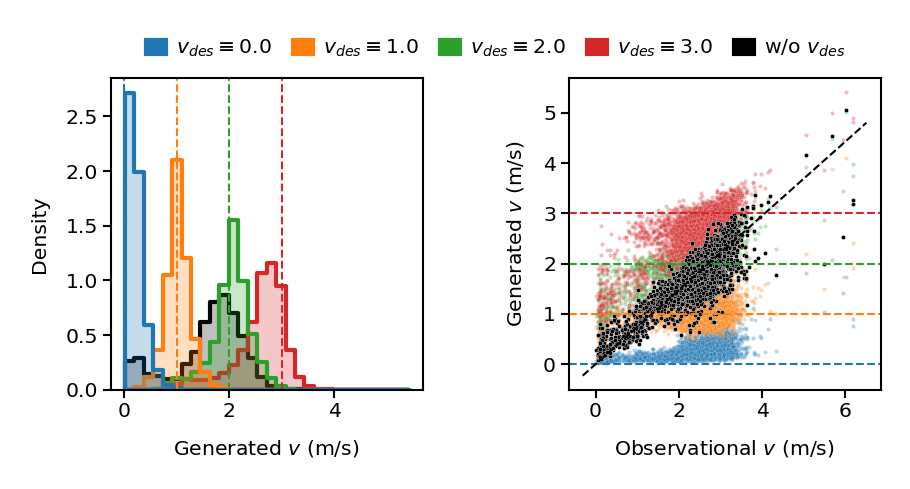

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from src.utils.plot import get_fig

fi, fig, axes = get_fig(1, 2, FW=8, A_ratio=1.0, HS=5, TM=3, BM=3)
ax = axes[0]

df_plot = pd.concat([
    # pd.Series(records_normal['spd_pred'][:, -1]).to_frame('speed').assign(setting='history'),
    pd.Series(records_set_to_0['spd_pred'][:, -1]).to_frame('speed').assign(setting='$v_{des}\\equiv0.0$'),
    pd.Series(records_set_to_1['spd_pred'][:, -1]).to_frame('speed').assign(setting='$v_{des}\\equiv1.0$'),
    pd.Series(records_set_to_2['spd_pred'][:, -1]).to_frame('speed').assign(setting='$v_{des}\\equiv2.0$'),
    pd.Series(records_set_to_3['spd_pred'][:, -1]).to_frame('speed').assign(setting='$v_{des}\\equiv3.0$'),
    pd.Series(records_set_to_nan['spd_pred'][:, -1]).to_frame('speed').assign(setting='w/o $v_{des}$'),
])
sns.histplot(data=df_plot, x='speed', hue='setting', element='step', stat='density', common_norm=False, bins=30, ax=ax, rasterized=True, legend=False, palette=['C0', 'C1', 'C2', 'C3', 'black'])
# df_plot = pd.Series(records_set_to_nan['spd_pred'][:, -1]).to_frame('speed').assign(setting='w/o $v_{des}$')
# sns.histplot(data=df_plot, x='speed', element='step', stat='density', common_norm=False, bins=30, ax=ax, rasterized=True, color='black', zorder=-1)
ax.axvline(0.0, color='C0', linestyle='--')
ax.axvline(1.0, color='C1', linestyle='--')
ax.axvline(2.0, color='C2', linestyle='--')
ax.axvline(3.0, color='C3', linestyle='--')
ax.set_xlabel('Generated $v$ (m/s)', fontsize=0.7*fi['fontsize'])
ax.set_ylabel('Density', fontsize=0.7*fi['fontsize'])
ax.tick_params(axis='both', which='major', labelsize=0.7*fi['fontsize'], length=2, pad=1)

ax = axes[1]
dropzero = lambda x: np.where(x==0.0, np.nan, x)
sns.scatterplot(x=dropzero(records_set_to_0['spd_hist'][:, -1]), y=records_set_to_0['spd_pred'][:, -1], alpha=0.3, ax=ax, s=1, rasterized=True)
sns.scatterplot(x=dropzero(records_set_to_1['spd_hist'][:, -1]), y=records_set_to_1['spd_pred'][:, -1], alpha=0.3, ax=ax, s=1, rasterized=True)
sns.scatterplot(x=dropzero(records_set_to_2['spd_hist'][:, -1]), y=records_set_to_2['spd_pred'][:, -1], alpha=0.3, ax=ax, s=1, rasterized=True)
sns.scatterplot(x=dropzero(records_set_to_3['spd_hist'][:, -1]), y=records_set_to_3['spd_pred'][:, -1], alpha=0.3, ax=ax, s=1, rasterized=True)
sns.scatterplot(x=dropzero(records_set_to_nan['spd_hist'][:, -1]), y=records_set_to_nan['spd_pred'][:, -1], alpha=1.0, ax=ax, s=1, color='black', rasterized=True)
ax.axhline(0.0, color='C0', linestyle='--')
ax.axhline(1.0, color='C1', linestyle='--')
ax.axhline(2.0, color='C2', linestyle='--')
ax.axhline(3.0, color='C3', linestyle='--')
x = dropzero(records_set_to_nan['spd_hist'][:, -1])
y = records_set_to_nan['spd_pred'][:, -1]
xlim = ax.get_xlim()
# a, b = np.polyfit(x[~np.isnan(x)], y[~np.isnan(x)], 1)
# ax.plot(xlim, a * np.array(xlim) + b, color='black', linestyle='--')
a, residuals, rank, s = np.linalg.lstsq(x[~np.isnan(x)][:, np.newaxis], y[~np.isnan(x)], rcond=None)
ax.plot(xlim, a[0] * np.array(xlim), color='black', linestyle='--', label=f'w/o $v_{{des}}$')
ax.set_xlabel('Observational $v$ (m/s)', fontsize=0.7*fi['fontsize'])
ax.set_ylabel('Generated $v$ (m/s)', fontsize=0.7*fi['fontsize'])
ax.tick_params(axis='both', which='major', labelsize=0.7*fi['fontsize'], length=2, pad=1)

fig.legend(
    [
        plt.Rectangle((0,0),1,1, color='C0'),
        plt.Rectangle((0,0),1,1, color='C1'),
        plt.Rectangle((0,0),1,1, color='C2'),
        plt.Rectangle((0,0),1,1, color='C3'),
        plt.Rectangle((0,0),1,1, color='black'),
    ],
    [
        '$v_{des}\\equiv0.0$',
        '$v_{des}\\equiv1.0$',
        '$v_{des}\\equiv2.0$',
        '$v_{des}\\equiv3.0$',
        'w/o $v_{des}$',
    ],
    loc='lower center',
    bbox_to_anchor=fi['top_box'],
    fontsize=0.7*fi['fontsize'],
    ncol=5,
    columnspacing=1.0,
    handletextpad=0.5,
    handlelength=1,
    frameon=False,
)

Path('figures').mkdir(parents=True, exist_ok=True)
fig.savefig('figures/control_speed.pdf', bbox_inches='tight', dpi=300, transparent=True)
fig.savefig('figures/control_speed.png', bbox_inches='tight', dpi=300, transparent=True)
fig.savefig('figures/control_speed.svg', bbox_inches='tight', dpi=300, transparent=True)

In [27]:
import time
from tqdm import tqdm
from src.tasks.simulate import SimulateState
from src.tasks.guidance import guidance

def foo2(args, test_loaders, set_des_y_to=None, with_guidance=False):
    torch.set_grad_enabled(False)
    model.eval()

    records = dict(pos=[], des=[], pos_pred=[], pos_true=[], direction=[])
    for loader in test_loaders:
        map_data = loader.dataset.map_data
        map = torch.from_numpy(map_data.map).to(args.device).float()
        model.set_map_embedding(
            map=map,
            xmin=map_data.xmin,
            xmax=map_data.xmax,
            ymin=map_data.ymin,
            ymax=map_data.ymax,
        )
        for batch_idx, batch in enumerate(tqdm(loader, disable=False, leave=False, dynamic_ncols=True)):
            pos = batch['pos'].to(args.device)  # (batch_size, #pedestrian, 2)
            vel = batch['vel'].to(args.device)  # (batch_size, #pedestrian, 2)
            hst = batch['hst'].to(args.device)  # (batch_size, #pedestrian, hist_step, 2)
            des = batch['des'].to(args.device)  # (batch_size, #pedestrian, 2)
            spd = batch['spd'].to(args.device)  # (batch_size, #pedestrian, 1)
            veh = batch['veh'].to(args.device)  # (batch_size, #vehicle, hist_step + 1, 2)
            future_acc = batch['future_acc'].to(args.device)  # (batch_size, #pedestrian, pred_step*roll_step, 2)
            future_pos = batch['future_pos'].to(args.device)  # (batch_size, #pedestrian, pred_step*roll_step, 2)
            future_veh = batch['future_veh'].to(args.device)  # (batch_size, #vehicle, pred_step*roll_step, 2)
            ped_length = batch['ped_length'].to(args.device)  # (batch_size,)
            veh_length = batch['veh_length'].to(args.device)  # (batch_size,)

            if set_des_y_to is None:
                pass
            elif isinstance(set_des_y_to, float) and np.isnan(set_des_y_to):
                des[:] = float('nan')
            else:
                des[..., 1] = set_des_y_to

            S = args.sample_num  # 采样次数
            N = args.denoise_step  # 采样步数
            assert args.T % N == 0, f"试图使用 {N} 步采样，然而训练步数 {args.T} mod {N} 不等于 0!"
            assert 1 <= args.step_offset <= args.T // N, f"step_offset 应该取值于 {{1, ..., {args.T // N}}}!"
            pos_now = pos.repeat(S, 1, 1)  # (S*B, #pedestrian, 2)
            vel_now = vel.repeat(S, 1, 1)  # (S*B, #pedestrian, 2)
            hst_now = hst.repeat(S, 1, 1, 1)  # (S*B, #pedestrian, hist_step, 2)
            des_now = des.repeat(S, 1, 1)  # (S*B, #pedestrian, 2)
            spd_now = spd.repeat(S, 1, 1)  # (S*B, #pedestrian, 1)
            veh_now = veh.repeat(S, 1, 1, 1)  # (S*B, #vehicle, hist_step + 1, 2)
            ped_length_repeat = ped_length.repeat(S)  # (S*B,)
            veh_length_repeat = veh_length.repeat(S)  # (S*B,)

            for_plot = []
            acc_pred = []
            for step in range(args.roll_step):
                model.set_veh_embedding(veh=veh_now)
                model.set_ped_embedding(pos=pos_now, vel=vel_now, hst=hst_now, des=des_now, spd=spd_now)
                model.set_sur_info()

                shape = list(future_acc.shape)
                shape[0] *= S
                shape[2] = args.pred_step
                xt = torch.randn(shape, device=args.device)  # 从噪声开始
                for_plot.append([diffusion.noise_to_x0(xt=xt, denoise_t=args.T, noise=0) / args.scale_accelerate])
                stride = args.T // N
                steps = reversed(range(args.step_offset, args.T+1, stride))
                for t in tqdm(steps, disable=True, leave=False, dynamic_ncols=True):
                    noisy_acc = xt
                    denoise_t = torch.full((xt.shape[0],), t, device=args.device, dtype=torch.long)
                    output = model(
                        noisy_acc=noisy_acc, 
                        denoise_t=denoise_t,
                        ped_length=ped_length_repeat, 
                        veh_length=veh_length_repeat,
                    )  # (S*B, #pedestrian, pred_step, 2)
                    ## 获取估计的 x0
                    x0 = diffusion.noise_to_x0(xt, denoise_t, output) if args.predict_noise else output
                    ## 尝试各种引导，各种 guidance 应为 0~1 左右的系数
                    if with_guidance:
                        state = SimulateState(
                            df_ped=None, df_veh=None, map_data=None, 
                            ped_list=None, veh_list=None, frame=None,
                            pos_now=pos_now, vel_now=vel_now, des_now=des_now, 
                            hst_now=hst_now, spd_now=spd_now, veh_now=veh_now,
                        )
                        x0 = x0 + guidance(args, x0, state, model, diffusion, noisy_acc, xt, denoise_t, ped_length_repeat, veh_length_repeat)
                    ## 去噪
                    xt = diffusion.denoise(xt, t, x0=x0, stride=min(stride, t))
                    for_plot[-1].append(x0 / args.scale_accelerate)

                acc_new = xt / args.scale_accelerate  # (S*B, #pedestrian, pred_step, 2)
                acc_pred.append(acc_new)

                vel_new = vel_now.unsqueeze(-2) + acc_new.cumsum(dim=-2) / args.fps  # (S*B, #pedestrian, pred_step, 2)
                pos_new = pos_now.unsqueeze(-2) + vel_new.cumsum(dim=-2) / args.fps  # (S*B, #pedestrian, pred_step, 2)
                veh_new = future_veh[:, :, step*args.pred_step:(step+1)*args.pred_step, :].repeat(S, 1, 1, 1)  # (S*B, #vehicle, pred_step, 2)

                hst_now = torch.cat([hst_now, pos_now.unsqueeze(-2), pos_new], dim=-2)[:, :, -args.hist_step-1:-1, :] # (S*B, #pedestrian, hist_step, 2)
                veh_now = torch.cat([veh_now, veh_new], dim=-2)[:, :, -args.hist_step-1:, :]  # (S*B, #vehicle, hist_step + 1, 2)
                pos_now = pos_new[:, :, -1, :] # (S*B, #pedestrian, 2)
                vel_now = vel_new[:, :, -1, :] # (S*B, #pedestrian, 2)

            acc_pred = torch.concat(acc_pred, dim=-2)  # (S*B, #pedestrian, roll_step*pred_step, 2)
            batch_size, ped_num, _, _ = future_acc.shape
            acc_pred = acc_pred.view(S, batch_size, ped_num, args.roll_step*args.pred_step, 2)  # (S, B, #pedestrian, roll_step*pred_step, 2)
            mask = torch.arange(ped_num, device=args.device).expand(batch_size, ped_num) < ped_length.unsqueeze(-1)  # (B, #pedestrian)

            acc_true = future_acc # (B, #pedestrian, roll_step*pred_step, 2)
            vel_true = vel.unsqueeze(-2) + acc_true.cumsum(dim=-2) / args.fps # (B, #pedestrian, roll_step*pred_step, 2)
            pos_true = pos.unsqueeze(-2) + vel_true.cumsum(dim=-2) / args.fps # (B, #pedestrian, roll_step*pred_step, 2)

            vel_pred = vel.unsqueeze(-2) + acc_pred.cumsum(dim=-2) / args.fps  # (S, B, #pedestrian, roll_step*pred_step, 2)
            pos_pred = pos.unsqueeze(-2) + vel_pred.cumsum(dim=-2) / args.fps  # (S, B, #pedestrian, roll_step*pred_step, 2)

            records['pos'].extend(pos[mask, :].tolist())
            records['des'].extend(des[mask, :].tolist())
            records['pos_pred'].extend(pos_pred[:, mask, :, :].mean(dim=0).tolist())
            records['pos_true'].extend(pos_true[mask, :, :].tolist())
            records['direction'].extend(((des - pos)[mask][:, 0] > 0).cpu().numpy().tolist())
    
    records['pos'] = np.array(records['pos'])  # (N, 2)
    records['des'] = np.array(records['des'])  # (N, 2)
    records['pos_pred'] = np.array(records['pos_pred'])  # (N, 12, 2)
    records['pos_true'] = np.array(records['pos_true'])  # (N, 12, 2)
    records['direction'] = np.array(records['direction'])  # (N,)
    return records

In [28]:
records_noset_des = foo2(args, test_loaders, set_des_y_to=None)
records_set_des_to_nan = foo2(args, test_loaders, set_des_y_to=float('nan'))
records_set_des_y_to_n2 = foo2(args, test_loaders, set_des_y_to=-2)
records_set_des_y_to_12 = foo2(args, test_loaders, set_des_y_to=12)

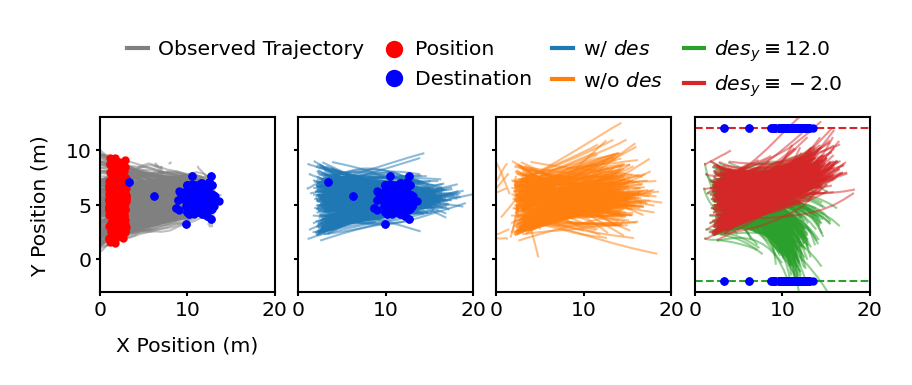

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from src.utils.plot import get_fig

mask = records_noset_des['direction'] & (records_noset_des['pos'][:, 0] > 1) & (records_noset_des['pos'][:, 0] < 3)

fi, fig, axes = get_fig(1, 4, FW=8, A_ratio=1.0, HS=0.8, sharex=True, sharey=True)
ax_loader = iter(axes)

ax = next(ax_loader)
for pid, trace in test_dataset[0].df_data.groupby('id'):
    trace = trace.sort_values('f')
    ax.plot(trace['x'], trace['y'], color='gray', alpha=0.5, linewidth=0.5, rasterized=True)
ax.scatter(records_noset_des['pos'][mask, 0], records_noset_des['pos'][mask, 1], color='red', s=1, zorder=99999, rasterized=True)
ax.scatter(records_noset_des['des'][mask, 0], records_noset_des['des'][mask, 1], color='blue', s=1, zorder=99999, rasterized=True)
ax.set_xlabel('X Position (m)', fontsize=0.7*fi['fontsize'])
ax.set_ylabel('Y Position (m)', fontsize=0.7*fi['fontsize'])
ax.set_xlim(0, 20)
ax.set_ylim(-3, 13)
# ax.set_xticks([0, 10])
ax.tick_params(axis='both', which='major', labelsize=0.7*fi['fontsize'], length=1, pad=1)

ax = next(ax_loader)
traces = records_noset_des['pos_pred'][mask]
for trace in traces:
    ax.plot(trace[:, 0], trace[:, 1], color='C0', alpha=0.5, linewidth=0.5, rasterized=True)
ax.scatter(records_noset_des['des'][mask, 0], records_noset_des['des'][mask, 1], color='blue', s=1, zorder=99999, rasterized=True)
ax.tick_params(axis='both', which='major', labelsize=0.7*fi['fontsize'], length=1, pad=1)

ax = next(ax_loader)
traces = records_set_des_to_nan['pos_pred'][mask]
for trace in traces:
    ax.plot(trace[:, 0], trace[:, 1], color='C1', alpha=0.5, linewidth=0.5, rasterized=True)
ax.tick_params(axis='both', which='major', labelsize=0.7*fi['fontsize'], length=1, pad=1)


ax = next(ax_loader)
traces = records_set_des_y_to_n2['pos_pred'][mask]
for trace in traces:
    ax.plot(trace[:, 0], trace[:, 1], color='C2', alpha=0.5, linewidth=0.5, rasterized=True)
# ax.scatter(records_set_des_y_to_n2['des'][mask, 0], records_set_des_y_to_n2['des'][mask, 1], color='blue', s=5, rasterized=True)
ax.axhline(-2, color='C2', linestyle='--')
ax.axhline(12, color='C3', linestyle='--')
ax.scatter(records_noset_des['des'][mask, 0], -2 + 0 * records_noset_des['des'][mask, 1], color='blue', s=1, zorder=99999, rasterized=True)
ax.scatter(records_noset_des['des'][mask, 0], 12 + 0 * records_noset_des['des'][mask, 1], color='blue', s=1, zorder=99999, rasterized=True)
ax.tick_params(axis='both', which='major', labelsize=0.7*fi['fontsize'], length=1, pad=1)

traces = records_set_des_y_to_12['pos_pred'][mask]
for trace in traces:
    ax.plot(trace[:, 0], trace[:, 1], color='C3', alpha=0.5, linewidth=0.5, rasterized=True)
# ax.scatter(records_set_des_y_to_12['des'][mask, 0], records_set_des_y_to_12['des'][mask, 1], color='green', s=5, rasterized=True)



fig.legend(
    [
        plt.Line2D([], [], color='gray', lw=1),
        plt.Line2D([], [], color='none', alpha=0, lw=1),
        plt.scatter([], [], color='red', s=10),
        plt.scatter([], [], color='blue', s=10),
        plt.Line2D([], [], color='C0', lw=1),
        plt.Line2D([], [], color='C1', lw=1),
        plt.Line2D([], [], color='C2', lw=1),
        plt.Line2D([], [], color='C3', lw=1),
    ],
    [
        'Observed Trajectory',
        None,
        'Position',
        'Destination',
        'w/ $des$',
        'w/o $des$',
        '$des_y \\equiv 12.0$',
        '$des_y \\equiv -2.0$',
    ],
    ncol=4,
    bbox_to_anchor=fi['top_box'],
    loc='lower center',
    columnspacing=1.0,
    handletextpad=0.5,
    handlelength=1,
    frameon=False,
    fontsize=0.7*fi['fontsize']
)

Path('figures').mkdir(parents=True, exist_ok=True)
fig.savefig('figures/control_destination.pdf', bbox_inches='tight', dpi=300, transparent=True)
fig.savefig('figures/control_destination.png', bbox_inches='tight', dpi=300, transparent=True)
fig.savefig('figures/control_destination.svg', bbox_inches='tight', dpi=300, transparent=True)